In [1]:
pip install pandas matplotlib numpy openpyxl



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


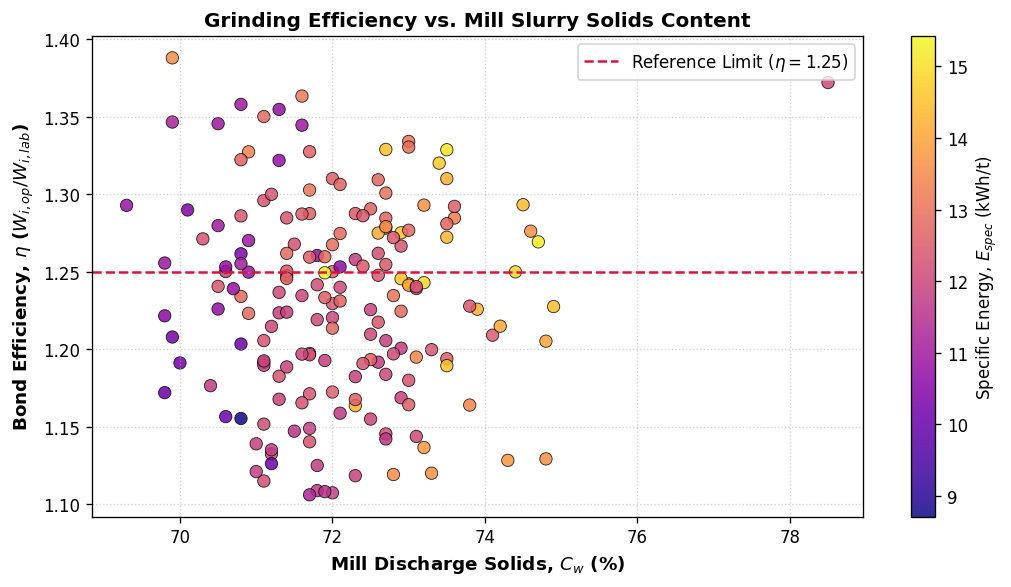

In [3]:
# 1. بارگذاری داده‌های آسیاب
excel_path = "/home/qc/Data_Ch01_Ch02.xlsx"  # یا مسیر دلخواهت

df_energy = pd.read_excel(excel_path, sheet_name="Ch02_Grinding_Mill_Energy")

# 2. نام ستون‌های دقیق مطابق شیت اکسل
col_solids = "Mill_Discharge_Cw_pct"  # درصد جامد خروجی آسیاب
col_eta = "Bond_Efficiency_Eta"  # شاخص کارایی باند (Wi_op / Wi_lab)
col_espec = "E_spec_Plant_kWh_t"  # انرژی ویژه مصرفی (kWh/t)

# اعتبارسنجی ستون‌ها
required_columns = [col_solids, col_eta, col_espec]
missing = [c for c in required_columns if c not in df_energy.columns]
if missing:
    raise ValueError(f"ستون‌های یافت‌نشده در اکسل: {missing}")

# 3. ترسیم نمودار اسکتر سه‌متغیره
plt.figure(figsize=(9, 5), dpi=120)

scatter = plt.scatter(
    df_energy[col_solids],
    df_energy[col_eta],
    c=df_energy[col_espec],
    cmap="plasma",  # تم plasma یا viridis تفکیک رنگی عالی برای انرژی میده
    edgecolor="k",
    linewidth=0.5,
    alpha=0.85,
    s=55,
)

# 4. خط مرجع کارایی باند
plt.axhline(
    y=1.25,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="Reference Limit ($\eta = 1.25$)",
)

# 5. نوار رنگی و برچسب‌ها
cbar = plt.colorbar(scatter)
cbar.set_label("Specific Energy, $E_{spec}$ (kWh/t)", fontsize=10)

plt.xlabel("Mill Discharge Solids, $C_w$ (%)", fontsize=11, fontweight="bold")
plt.ylabel(
    r"Bond Efficiency, $\eta$ ($W_{i,op} / W_{i,lab}$)",
    fontsize=11,
    fontweight="bold",
)
plt.title(
    "Grinding Efficiency vs. Mill Slurry Solids Content",
    fontsize=12,
    fontweight="bold",
)

plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, loc="upper right")
plt.tight_layout()

# ذخیره خروجی
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/ch02_energy_efficiency.png", dpi=300, bbox_inches="tight")
plt.show()
